# **xG - Goles Espererados - Modelo Machine Learning - Regresión Logística** *PARTE 2*

In [1]:
import pandas as pd
# from statsbombpy import sb  # Ya no se usa: los tiros se cargan desde CSV
from pathlib import Path
import numpy as np


pd.set_option("display.max_columns", None)

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
ruta_processed = Path("..") / "data" / "processed"

df_partidos_modelo = pd.read_csv(ruta_processed / "df_partidos_modelo.csv")

In [4]:
df_partidos_modelo.head()

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_id,competition_country_name,competition_name,competition,season_id,season,home_team_id,home_team,home_team_gender,home_team_group,home_team_country_id,home_team_country_name,away_team_id,away_team,away_team_gender,away_team_group,away_team_country_id,away_team_country_name,competition_stage_id,competition_stage,stadium_id,stadium,stadium_country_id,stadium_country_name,referee_id,referee,referee_country_id,referee_country_name,home_managers,away_managers,home_manager_id,home_manager_name,home_manager_nickname,home_manager_dob,home_manager_country_id,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version,season_name,season_year,country_name
0,3943077,2024-07-15,04:15:00.000,1,0,available,unscheduled,2024-07-15T15:50:08.671355,NaN,6,223,South America,Copa America,South America - Copa America,282,2024,779,Argentina,male,NaN,11,Argentina,769,Colombia,male,NaN,49,Colombia,26,Final,5337.0,Hard Rock Stadium,241.0,United States of America,2638.0,Raphael Claus,31.0,Brazil,Lionel Sebastián Scaloni,Néstor Gabriel Lorenzo,5677,Lionel Sebastián Scaloni,NaN,1978-05-16,11,Argentina,5905,Néstor Gabriel Lorenzo,NaN,1966-02-28,11,Argentina,1.1.0,2.0,2.0,2024,2024,South America
1,3943076,2024-07-14,03:00:00.000,2,2,available,unscheduled,2024-07-15T07:57:02.660641,NaN,6,223,South America,Copa America,South America - Copa America,282,2024,1833,Canada,male,NaN,40,Canada,783,Uruguay,male,NaN,242,Uruguay,25,3rd Place Final,52985.0,Bank of America Stadium,241.0,United States of America,1849.0,Alexis Herrera,246.0,Venezuela (Bolivarian Republic),Jesse Marsch,Marcelo Alberto Bielsa Caldera,165,Jesse Marsch,NaN,1973-11-08,241,United States of America,269,Marcelo Alberto Bielsa Caldera,Marcelo Bielsa,1955-07-21,11,Argentina,1.1.0,2.0,2.0,2024,2024,South America
2,3942852,2024-07-11,03:00:00.000,0,1,available,unscheduled,2024-07-15T18:00:33.653673,NaN,5,223,South America,Copa America,South America - Copa America,282,2024,783,Uruguay,male,NaN,242,Uruguay,769,Colombia,male,NaN,49,Colombia,15,Semi-finals,52985.0,Bank of America Stadium,241.0,United States of America,740.0,César Arturo Ramos Palazuelos,147.0,Mexico,Marcelo Alberto Bielsa Caldera,Néstor Gabriel Lorenzo,269,Marcelo Alberto Bielsa Caldera,Marcelo Bielsa,1955-07-21,11,Argentina,5905,Néstor Gabriel Lorenzo,NaN,1966-02-28,11,Argentina,1.1.0,2.0,2.0,2024,2024,South America
3,3942785,2024-07-10,03:00:00.000,2,0,available,unscheduled,2024-07-14T15:55:49.351182,NaN,5,223,South America,Copa America,South America - Copa America,282,2024,779,Argentina,male,NaN,11,Argentina,1833,Canada,male,NaN,40,Canada,15,Semi-finals,1001990.0,MetLife Stadium,241.0,United States of America,1776.0,Piero Maza Gomez,45.0,Chile,Lionel Sebastián Scaloni,Jesse Marsch,5677,Lionel Sebastián Scaloni,NaN,1978-05-16,11,Argentina,165,Jesse Marsch,NaN,1973-11-08,241,United States of America,1.1.0,2.0,2.0,2024,2024,South America
4,3942416,2024-07-07,01:00:00.000,5,0,available,unscheduled,2024-07-10T06:49:40.099252,NaN,4,223,South America,Copa America,South America - Copa America,282,2024,769,Colombia,male,NaN,49,Colombia,798,Panama,male,NaN,176,Panama,11,Quarter-finals,118193.0,State Farm Stadium,241.0,United States of America,252.0,Maurizio Mariani,112.0,Italy,Néstor Gabriel Lorenzo,Thomas Christiansen Tarín,5905,Néstor Gabriel Lorenzo,NaN,1966-02-28,11,Argentina,415,Thomas Christiansen Tarín,Thomas Christiansen,1973-03-11,214,Spain,1.1.0,2.0,2.0,2024,2024,South America


In [5]:
df_partidos_modelo["es_qatar_2022"] = (
    (df_partidos_modelo["competition_name"] == "FIFA World Cup") &
    (df_partidos_modelo["season_name"].astype(str) == "2022")
)

In [6]:
df_partidos_modelo["es_qatar_2022"].value_counts()

es_qatar_2022
False    2462
True       64
Name: count, dtype: int64

In [7]:
selecciones_aplicacion = [
    "Argentina",
    "France",
    "Morocco",
    "Croatia"
]

In [8]:
df_partidos_modelo["juega_seleccion_aplicacion"] = (
    df_partidos_modelo["home_team"].isin(selecciones_aplicacion) |
    df_partidos_modelo["away_team"].isin(selecciones_aplicacion)
)

In [9]:
df_partidos_modelo["juega_seleccion_aplicacion"].value_counts()

juega_seleccion_aplicacion
False    2458
True       68
Name: count, dtype: int64

In [10]:
df_partidos_modelo["es_partido_aplicacion"] = (
    (df_partidos_modelo["es_qatar_2022"] == True) &
    (df_partidos_modelo["juega_seleccion_aplicacion"] == True)
)

In [11]:
df_partidos_modelo["es_partido_aplicacion"].value_counts()

es_partido_aplicacion
False    2503
True       23
Name: count, dtype: int64

In [12]:
df_partidos_aplicacion = df_partidos_modelo[
    df_partidos_modelo["es_partido_aplicacion"] == True
].copy()

df_partidos_aplicacion[
    [
        "match_id",
        "match_date",
        "competition_name",
        "season_name",
        "home_team",
        "away_team",
        "home_score",
        "away_score"
    ]
].sort_values("match_date")

,match_id,match_date,competition_name,season_name,home_team,away_team,home_score,away_score
224,3857279,2022-11-22,FIFA World Cup,2022,France,Australia,4,1
212,3857300,2022-11-22,FIFA World Cup,2022,Argentina,Saudi Arabia,1,2
226,3857277,2022-11-23,FIFA World Cup,2022,Morocco,Croatia,0,0
187,3857266,2022-11-26,FIFA World Cup,2022,France,Denmark,2,1
188,3857289,2022-11-26,FIFA World Cup,2022,Argentina,Mexico,2,0
222,3857281,2022-11-27,FIFA World Cup,2022,Croatia,Canada,4,1
207,3857283,2022-11-27,FIFA World Cup,2022,Belgium,Morocco,0,2
228,3857275,2022-11-30,FIFA World Cup,2022,Tunisia,France,1,0
186,3857264,2022-11-30,FIFA World Cup,2022,Poland,Argentina,0,2
216,3857296,2022-12-01,FIFA World Cup,2022,Croatia,Belgium,0,0


In [13]:
df_partidos_entrenamiento_base = df_partidos_modelo[
    df_partidos_modelo["es_partido_aplicacion"] == False
].copy()

In [14]:
match_ids_modelo = df_partidos_modelo["match_id"].drop_duplicates().tolist()

In [15]:
# CELDA DESACTIVADA
# Esta descarga consultaba StatsBomb con sb.events().
# Se deja comentada para que el notebook pueda ejecutarse sin consultar statsbombpy.

# lista_tiros = []
# 
# for match_id in match_ids_modelo:
#     
#     print("Descargando partido:", match_id)
#     
#     df_eventos_partido = sb.events(match_id=match_id)
#     
#     df_tiros_partido = df_eventos_partido[df_eventos_partido["type"] == "Shot"].copy()
#     
#     df_tiros_partido["match_id"] = match_id
#     
#     lista_tiros.append(df_tiros_partido)

In [44]:
# CELDA DESACTIVADA
# Antes se concatenaba la lista generada por sb.events().
# Ahora df_tiros_completo se carga directamente desde df_tiros_completo_crudo.csv.

# df_tiros_completo = pd.concat(lista_tiros, ignore_index=True)

## Carga de tiros desde CSV

A partir de este punto el notebook no consulta `statsbombpy`. Se usa el archivo ya descargado `df_tiros_completo_crudo.csv` desde `data/processed`.


In [16]:
import ast

df_tiros_completo = pd.read_csv(ruta_processed / "df_tiros_completo_crudo.csv")

def convertir_location(valor):
    
    if pd.isna(valor):
        return np.nan
    
    return ast.literal_eval(valor)

df_tiros_completo["location"] = df_tiros_completo["location"].apply(convertir_location)

print("Tiros cargados desde CSV:", df_tiros_completo.shape[0])
print("Columnas cargadas desde CSV:", df_tiros_completo.shape[1])
print("Partidos con tiros:", df_tiros_completo["match_id"].nunique())

Tiros cargados desde CSV: 63740
Columnas cargadas desde CSV: 121
Partidos con tiros: 2526


In [17]:
print("Tiros:", df_tiros_completo.shape[0])
print("Columnas:", df_tiros_completo.shape[1])
print("Partidos con tiros:", df_tiros_completo["match_id"].nunique())

Tiros: 63740
Columnas: 121
Partidos con tiros: 2526


In [19]:
# CELDA DESACTIVADA
# El archivo df_tiros_completo_crudo.csv ya se usa como input.
# No lo volvemos a guardar para evitar sobrescribirlo accidentalmente.

# df_tiros_completo.to_csv(ruta_processed / "df_tiros_completo_crudo.csv", index=False)

In [20]:
columnas_partido = [
    "match_id",
    "match_date",
    "competition_name",
    "season_name",
    "season_year",
    "home_team",
    "away_team",
    "home_score",
    "away_score",
    "es_qatar_2022",
    "juega_seleccion_aplicacion",
    "es_partido_aplicacion"
]

df_info_partidos = df_partidos_modelo[columnas_partido].copy()

In [21]:
df_tiros_completo = df_tiros_completo.merge(
    df_info_partidos,
    on="match_id",
    how="left"
)

saco tanda de penales

In [22]:
df_tiros_modelo = df_tiros_completo[
    df_tiros_completo["period"] <= 4
].copy()

In [23]:
print("Tiros antes:", df_tiros_completo.shape[0])
print("Tiros después:", df_tiros_modelo.shape[0])

Tiros antes: 63740
Tiros después: 63482


In [24]:
df_tiros_modelo["gol"] = 0

df_tiros_modelo.loc[df_tiros_modelo["shot_outcome"] == "Goal","gol"] = 1

In [25]:
df_tiros_modelo["gol"].value_counts()

gol
0    56794
1     6688
Name: count, dtype: int64

In [26]:
print("Tasa de gol:", round(df_tiros_modelo["gol"].mean() * 100, 2), "%")

Tasa de gol: 10.54 %


coordenadas x e y

In [27]:
df_tiros_modelo = df_tiros_modelo[df_tiros_modelo["location"].notna()].copy()

In [28]:
df_tiros_modelo[["x", "y"]] = df_tiros_modelo["location"].apply(pd.Series)

In [29]:
df_tiros_modelo[["location", "x", "y"]].head()

,location,x,y
0,"[105.6, 44.0]",105.6,44.0
1,"[98.6, 25.2]",98.6,25.2
2,"[105.5, 47.3]",105.5,47.3
3,"[113.4, 38.7]",113.4,38.7
4,"[106.2, 36.8]",106.2,36.8


distancia al centro del arco

In [30]:
df_tiros_modelo["distancia_arco"] = np.sqrt((120 - df_tiros_modelo["x"]) ** 2 + (40 - df_tiros_modelo["y"]) ** 2)

In [31]:
df_tiros_modelo[["x", "y", "distancia_arco"]].head()

,x,y,distancia_arco
0,105.6,44.0,14.945233
1,98.6,25.2,26.019224
2,105.5,47.3,16.233915
3,113.4,38.7,6.726812
4,106.2,36.8,14.166157


distancia a los postes para calcular el ángulo

In [32]:
df_tiros_modelo["distancia_poste_1"] = np.sqrt( (120 - df_tiros_modelo["x"]) ** 2 + (36 - df_tiros_modelo["y"]) ** 2 )

df_tiros_modelo["distancia_poste_2"] = np.sqrt( (120 - df_tiros_modelo["x"]) ** 2 + (44 - df_tiros_modelo["y"]) ** 2 )

ángulo según cálculo de postes

In [33]:
ancho_arco = 8

valor_angulo = ( df_tiros_modelo["distancia_poste_1"] ** 2 + df_tiros_modelo["distancia_poste_2"] ** 2 - ancho_arco ** 2 ) / (2 *df_tiros_modelo["distancia_poste_1"] *df_tiros_modelo["distancia_poste_2"])

In [34]:
valor_angulo = np.clip(valor_angulo, -1, 1)

df_tiros_modelo["angulo_tiro"] = np.arccos(valor_angulo)

In [35]:
df_tiros_modelo[["x", "y", "distancia_arco", "angulo_tiro"]].head()

,x,y,distancia_arco,angulo_tiro
0,105.6,44.0,14.945233,0.507099
1,98.6,25.2,26.019224,0.253433
2,105.5,47.3,16.233915,0.438223
3,113.4,38.7,6.726812,1.064905
4,106.2,36.8,14.166157,0.538793


In [79]:
variables_numericas = [#"x", "y", 
                       "distancia_arco", "angulo_tiro"]

In [120]:
variables_categoricas = ["shot_body_part", "shot_type", "shot_technique", #"play_pattern", 
                         "under_pressure", "position"]

creo columnas vacías en caso de que diferencias de columnas en statsbomb

In [121]:
for columna in variables_categoricas:
    if columna not in df_tiros_modelo.columns:
        df_tiros_modelo[columna] = np.nan

In [122]:
for columna in variables_categoricas:
    df_tiros_modelo[columna] = df_tiros_modelo[columna].fillna("Sin dato")
    df_tiros_modelo[columna] = df_tiros_modelo[columna].astype(str)

In [123]:
df_tiros_modelo[variables_categoricas].head()

,shot_body_part,shot_type,shot_technique,under_pressure,position
0,Right Foot,Open Play,Half Volley,Sin dato,Left Center Forward
1,Right Foot,Open Play,Normal,Sin dato,Left Center Forward
2,Right Foot,Open Play,Half Volley,True,Right Center Forward
3,Head,Open Play,Normal,True,Left Center Back
4,Left Foot,Open Play,Normal,Sin dato,Right Center Forward


In [124]:
columnas_identificacion = [
    "match_id", "match_date",
    "competition_name", "season_name",
    "season_year", "home_team",
    "away_team", "team",
    "player", "minute",
    "second", "shot_outcome",
    "shot_statsbomb_xg", "es_qatar_2022",
    "juega_seleccion_aplicacion", "es_partido_aplicacion"]

In [125]:
for columna in columnas_identificacion:
    if columna not in df_tiros_modelo.columns:
        df_tiros_modelo[columna] = np.nan

In [126]:
columnas_modelo = ( columnas_identificacion + variables_numericas + variables_categoricas + ["gol"] )

In [127]:
df_modelo_xg = df_tiros_modelo[columnas_modelo].copy()

In [128]:
df_modelo_xg.shape

(63482, 24)

In [129]:
df_modelo_xg.to_csv(ruta_processed / "df_modelo_xg_completo.csv", index=False)

separo partidos de aplicación

In [130]:
df_modelo_aplicacion = df_modelo_xg[df_modelo_xg["es_partido_aplicacion"] == True].copy()

In [131]:
df_modelo_entrenamiento_base = df_modelo_xg[df_modelo_xg["es_partido_aplicacion"] == False].copy()

genero las bases para entrenar y validar • GroupShuffleSplit separa en grupos (en este caso matches y no acciones)

In [132]:
from sklearn.model_selection import GroupShuffleSplit

In [133]:
X_base = df_modelo_entrenamiento_base[variables_numericas + variables_categoricas].copy()

y_base = df_modelo_entrenamiento_base["gol"].copy()

grupos = df_modelo_entrenamiento_base["match_id"].copy()

In [134]:
separador = GroupShuffleSplit( n_splits=1, test_size=0.25, random_state=2026 )

In [135]:
indices_train, indices_test = next(separador.split(X_base, y_base, grupos))

df_modelo_train = df_modelo_entrenamiento_base.iloc[indices_train].copy()
df_modelo_test = df_modelo_entrenamiento_base.iloc[indices_test].copy()

In [136]:
print("Tiros train:", df_modelo_train.shape[0])
print("Tiros test:", df_modelo_test.shape[0])
print("Tiros aplicación:", df_modelo_aplicacion.shape[0])

Tiros train: 47082
Tiros test: 15890
Tiros aplicación: 510


separo X_train, X_test, y_train, y_test, X_aplicacion , y_aplicacion

In [137]:
X_train = df_modelo_train[variables_numericas + variables_categoricas].copy()

X_test = df_modelo_test[variables_numericas + variables_categoricas].copy()

y_train = df_modelo_train["gol"].copy()

y_test = df_modelo_test["gol"].copy()

In [138]:
X_aplicacion = df_modelo_aplicacion[variables_numericas + variables_categoricas].copy()

y_aplicacion = df_modelo_aplicacion["gol"].copy()

In [139]:
X_aplicacion["shot_type"].value_counts()

shot_type
Open Play    481
Free Kick     18
Penalty       10
Corner         1
Name: count, dtype: int64

In [140]:
df_modelo_train.to_csv(ruta_processed / "df_modelo_xg_train.csv", index=False)

df_modelo_test.to_csv(ruta_processed / "df_modelo_xg_test.csv", index=False)

df_modelo_aplicacion.to_csv(ruta_processed / "df_modelo_xg_aplicacion.csv", index=False)

In [141]:
#   df_modelo_train = pd.read_csv(ruta_processed / "df_modelo_xg_train.csv")
#   
#   df_modelo_test = pd.read_csv(ruta_processed / "df_modelo_xg_test.csv")
#   
#   df_modelo_aplicacion = pd.read_csv(ruta_processed / "df_modelo_xg_aplicacion.csv")

In [142]:
X_train.isna().sum()

distancia_arco    0
angulo_tiro       0
shot_body_part    0
shot_type         0
shot_technique    0
under_pressure    0
position          0
dtype: int64

In [143]:
X_train_num = X_train[variables_numericas].copy()
X_test_num = X_test[variables_numericas].copy()
X_aplicacion_num = X_aplicacion[variables_numericas].copy()

In [144]:
X_train_cat = X_train[variables_categoricas].copy()
X_test_cat = X_test[variables_categoricas].copy()
X_aplicacion_cat = X_aplicacion[variables_categoricas].copy()

In [145]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [146]:
X_train_num_escalado = scaler.fit_transform(X_train_num)
X_test_num_escalado = scaler.transform(X_test_num)
X_aplicacion_num_escalado = scaler.transform(X_aplicacion_num)

In [147]:
X_train_num_escalado = pd.DataFrame(
    X_train_num_escalado,
    columns=variables_numericas
)

X_test_num_escalado = pd.DataFrame(
    X_test_num_escalado,
    columns=variables_numericas
)

X_aplicacion_num_escalado = pd.DataFrame(
    X_aplicacion_num_escalado,
    columns=variables_numericas
)

In [148]:
from sklearn.preprocessing import OneHotEncoder

In [149]:
onehot = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
    drop="first"
)

In [150]:
X_train_cat_encoded = onehot.fit_transform(X_train_cat)

X_test_cat_encoded = onehot.transform(X_test_cat)

X_aplicacion_cat_encoded = onehot.transform(X_aplicacion_cat)

In [151]:
columnas_onehot = onehot.get_feature_names_out(variables_categoricas)

In [152]:
X_train_cat_encoded = pd.DataFrame(
    X_train_cat_encoded,
    columns=columnas_onehot
)

X_test_cat_encoded = pd.DataFrame(
    X_test_cat_encoded,
    columns=columnas_onehot
)

X_aplicacion_cat_encoded = pd.DataFrame(
    X_aplicacion_cat_encoded,
    columns=columnas_onehot
)

In [153]:
print("Categóricas train:", X_train_cat_encoded.shape)
print("Categóricas test:", X_test_cat_encoded.shape)
print("Categóricas aplicación:", X_aplicacion_cat_encoded.shape)

Categóricas train: (47082, 37)
Categóricas test: (15890, 37)
Categóricas aplicación: (510, 37)


In [154]:
X_train_concat = pd.concat([X_train_num_escalado.reset_index(drop=True),X_train_cat_encoded.reset_index(drop=True)],axis=1)

X_test_concat = pd.concat([X_test_num_escalado.reset_index(drop=True),X_test_cat_encoded.reset_index(drop=True)],axis=1)

X_aplicacion_concat = pd.concat([X_aplicacion_num_escalado.reset_index(drop=True),X_aplicacion_cat_encoded.reset_index(drop=True)],axis=1)

In [155]:
X_train_final = X_train_concat[[
    "distancia_arco", 
    "shot_body_part_Right Foot", 
    "shot_body_part_Left Foot", 
    "shot_type_Open Play", 
    "angulo_tiro", 
    "shot_type_Free Kick", 
    "shot_technique_Half Volley", 
    "under_pressure_True", 
    "shot_technique_Volley", 
    "shot_technique_Lob", 
    "position_Left Center Back", 
    "position_Right Center Back"]].copy()

X_test_final = X_test_concat[X_train_final.columns.tolist()].copy()

X_aplicacion_final = X_aplicacion_concat[X_train_final.columns.tolist()].copy()


In [156]:
columnas_numericas_escaladas = X_train_num_escalado.columns.tolist()

columnas_onehot = X_train_cat_encoded.columns.tolist()

target_train = y_train.reset_index(drop=True)

In [157]:
print("Columnas numéricas escaladas:", len(columnas_numericas_escaladas))
print("Columnas one-hot:", len(columnas_onehot))
print("Columnas totales X_train_final:", X_train_final.shape[1])
print("Filas target:", len(target_train))

Columnas numéricas escaladas: 2
Columnas one-hot: 37
Columnas totales X_train_final: 12
Filas target: 47082


In [158]:
import matplotlib.pyplot as plt
import math
import pandas as pd

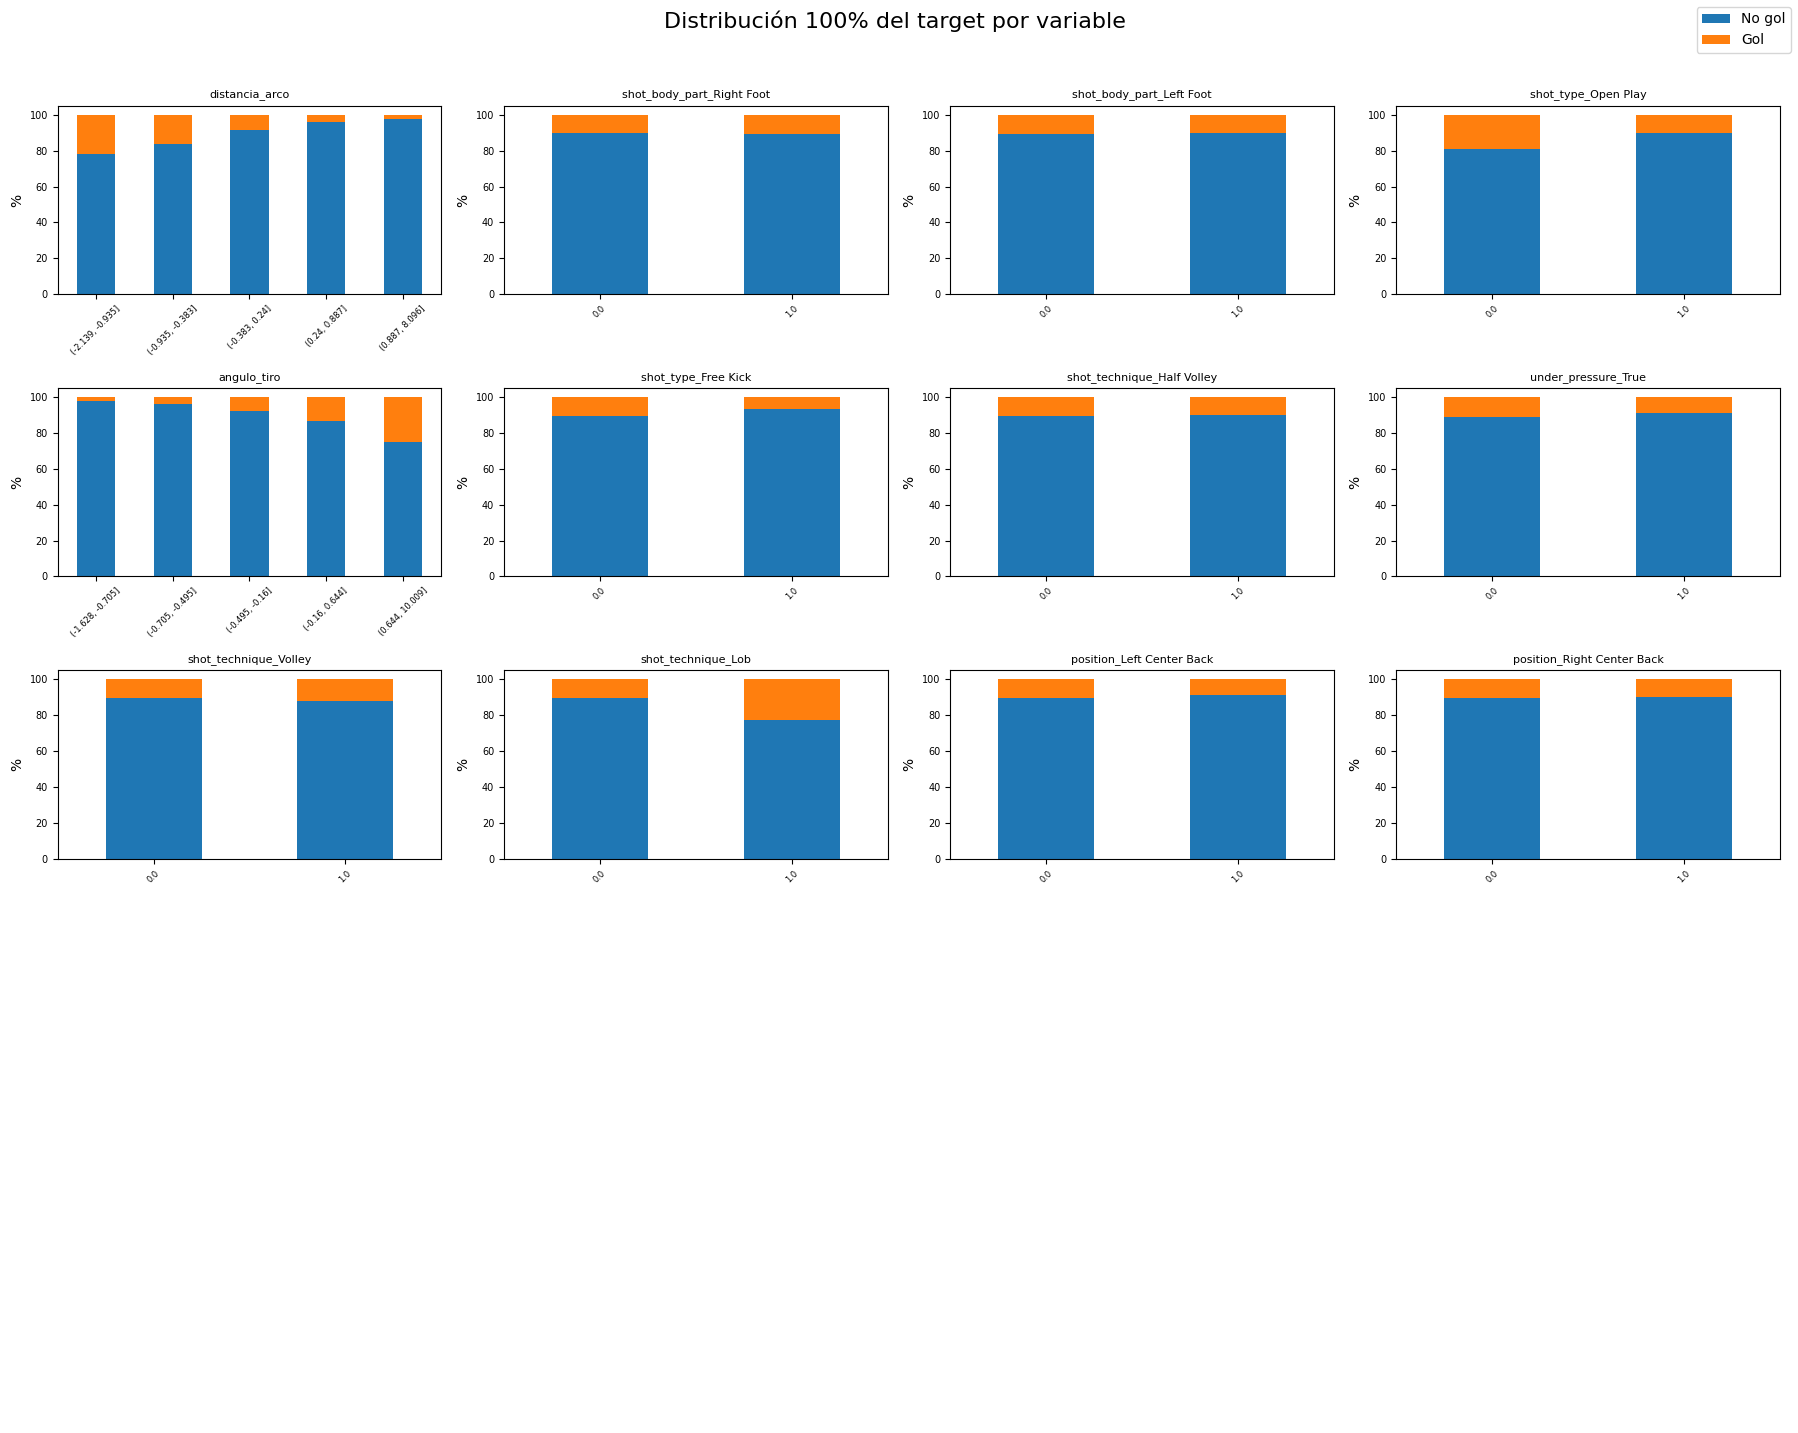

In [159]:
variables_a_graficar = X_train_final.columns.tolist()

graficos_por_figura = 20
columnas_figura = 4
filas_figura = math.ceil(graficos_por_figura / columnas_figura)

for inicio in range(0, len(variables_a_graficar), graficos_por_figura):
    
    fin = inicio + graficos_por_figura
    
    variables_bloque = variables_a_graficar[inicio:fin]
    
    fig, axes = plt.subplots(
        filas_figura,
        columnas_figura,
        figsize=(18, 14)
    )
    
    axes = axes.flatten()
    
    for i in range(len(variables_bloque)):
        
        variable = variables_bloque[i]
        ax = axes[i]
        
        df_grafico = pd.DataFrame()
        df_grafico["variable"] = X_train_final[variable].reset_index(drop=True)
        df_grafico["gol"] = target_train
        
        if variable in columnas_numericas_escaladas:
            
            df_grafico["grupo"] = pd.qcut(
                df_grafico["variable"],
                q=5,
                duplicates="drop"
            )
            
        else:
            
            df_grafico["grupo"] = df_grafico["variable"]
        
        tabla = pd.crosstab(
            df_grafico["grupo"],
            df_grafico["gol"],
            normalize="index"
        ) * 100
        
        if 0 not in tabla.columns:
            tabla[0] = 0
            
        if 1 not in tabla.columns:
            tabla[1] = 0
        
        tabla = tabla[[0, 1]]
        
        tabla.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            legend=False
        )
        
        ax.set_title(variable, fontsize=8)
        ax.set_xlabel("")
        ax.set_ylabel("%")
        ax.tick_params(axis="x", labelrotation=45, labelsize=6)
        ax.tick_params(axis="y", labelsize=7)
    
    for j in range(len(variables_bloque), len(axes)):
        axes[j].axis("off")
    
    fig.suptitle(
        "Distribución 100% del target por variable",
        fontsize=16,
        y=1.02
    )
    
    fig.legend(
        ["No gol", "Gol"],
        loc="upper right"
    )
    
    plt.tight_layout()
    plt.show()

In [160]:
df_corr_base = X_train_final.copy()

df_corr_base["gol"] = target_train

In [161]:
matriz_correlacion = df_corr_base.corr(method="pearson")

In [162]:
matriz_correlacion.shape

(13, 13)

In [163]:
correlacion_target = matriz_correlacion["gol"].drop("gol").sort_values(ascending=False)

correlacion_target.head(30)

angulo_tiro                   0.298505
shot_technique_Lob            0.038383
shot_technique_Volley         0.014521
shot_body_part_Right Foot     0.009451
shot_technique_Half Volley   -0.003564
position_Right Center Back   -0.005254
position_Left Center Back    -0.008937
shot_body_part_Left Foot     -0.010609
under_pressure_True          -0.027892
shot_type_Free Kick          -0.029419
shot_type_Open Play          -0.069311
distancia_arco               -0.244536
Name: gol, dtype: float64

In [164]:
correlacion_abs_target = matriz_correlacion["gol"].drop("gol").abs().sort_values(ascending=False)

correlacion_abs_target.head(30)

angulo_tiro                   0.298505
distancia_arco                0.244536
shot_type_Open Play           0.069311
shot_technique_Lob            0.038383
shot_type_Free Kick           0.029419
under_pressure_True           0.027892
shot_technique_Volley         0.014521
shot_body_part_Left Foot      0.010609
shot_body_part_Right Foot     0.009451
position_Left Center Back     0.008937
position_Right Center Back    0.005254
shot_technique_Half Volley    0.003564
Name: gol, dtype: float64

In [165]:
df_corr_target_grafico = pd.DataFrame()

df_corr_target_grafico["variable"] = correlacion_abs_target.head(30).index
df_corr_target_grafico["correlacion_abs"] = correlacion_abs_target.head(30).values

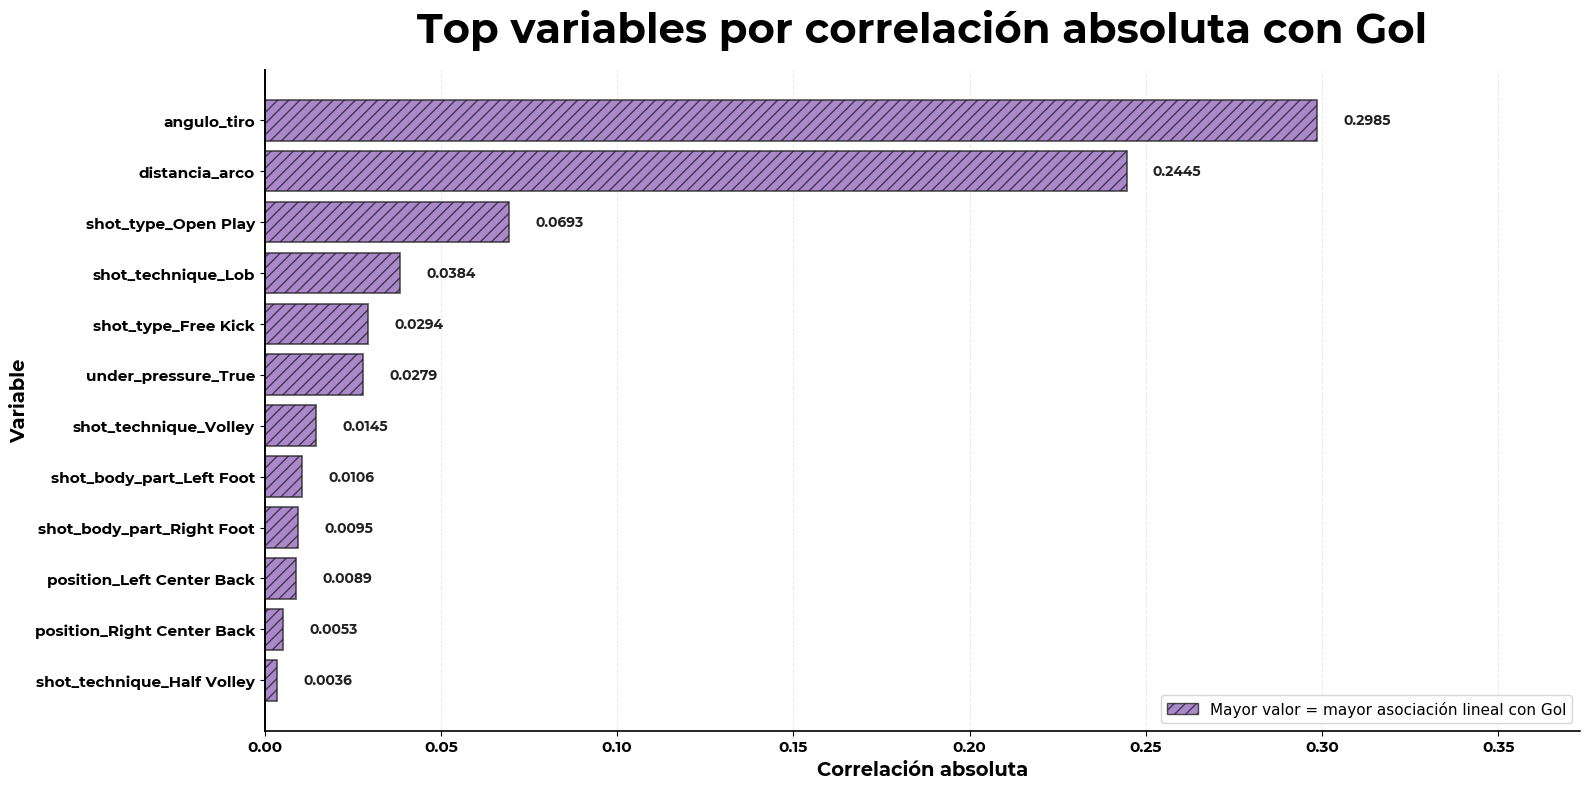

In [213]:
fuente_grafico = "Montserrat"

df_corr_target_grafico = df_corr_target_grafico.sort_values("correlacion_abs",ascending=True).copy()

fig, ax = plt.subplots(figsize=(16, 8))

barras = ax.barh(
    df_corr_target_grafico["variable"],
    df_corr_target_grafico["correlacion_abs"],
    color="tab:purple",
    alpha=0.78,
    edgecolor="#222222",
    linewidth=1.2)

for barra in barras:
    barra.set_hatch("///")

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.25)

ax.set_axisbelow(True)

ax.set_title(
    "Top variables por correlación absoluta con Gol",
    fontsize=30,
    fontweight="bold",
    fontname=fuente_grafico,
    pad=20)

ax.set_xlabel(
    "Correlación absoluta",
    fontsize=14,
    fontweight="bold",
    fontname=fuente_grafico)

ax.set_ylabel(
    "Variable",
    fontsize=14,
    fontweight="bold",
    fontname=fuente_grafico)

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

for etiqueta in ax.get_yticklabels():
    etiqueta.set_fontweight("bold")
    etiqueta.set_fontname(fuente_grafico)

for etiqueta in ax.get_xticklabels():
    etiqueta.set_fontweight("bold")
    etiqueta.set_fontname(fuente_grafico)

valor_maximo = df_corr_target_grafico["correlacion_abs"].max()

margen_derecho = valor_maximo * 0.25

ax.set_xlim(0,valor_maximo + margen_derecho)

desplazamiento = valor_maximo * 0.025

for barra in barras:
    
    ancho = barra.get_width()
    y = barra.get_y() + barra.get_height() / 2
    
    ax.text(
        ancho + desplazamiento,
        y,
        str(round(ancho, 4)),
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        fontname=fuente_grafico,
        color="#222222")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.4)
ax.spines["bottom"].set_linewidth(1.2)

correlacion_patch = plt.Rectangle(
    (0, 0),
    1,
    1,
    facecolor="tab:purple",
    edgecolor="#222222",
    hatch="///",
    alpha=0.78,
    label="Mayor valor = mayor asociación lineal con Gol")

ax.legend(
    handles=[correlacion_patch],
    loc="lower right",
    fontsize=11,
    frameon=True)

plt.tight_layout()
plt.show()

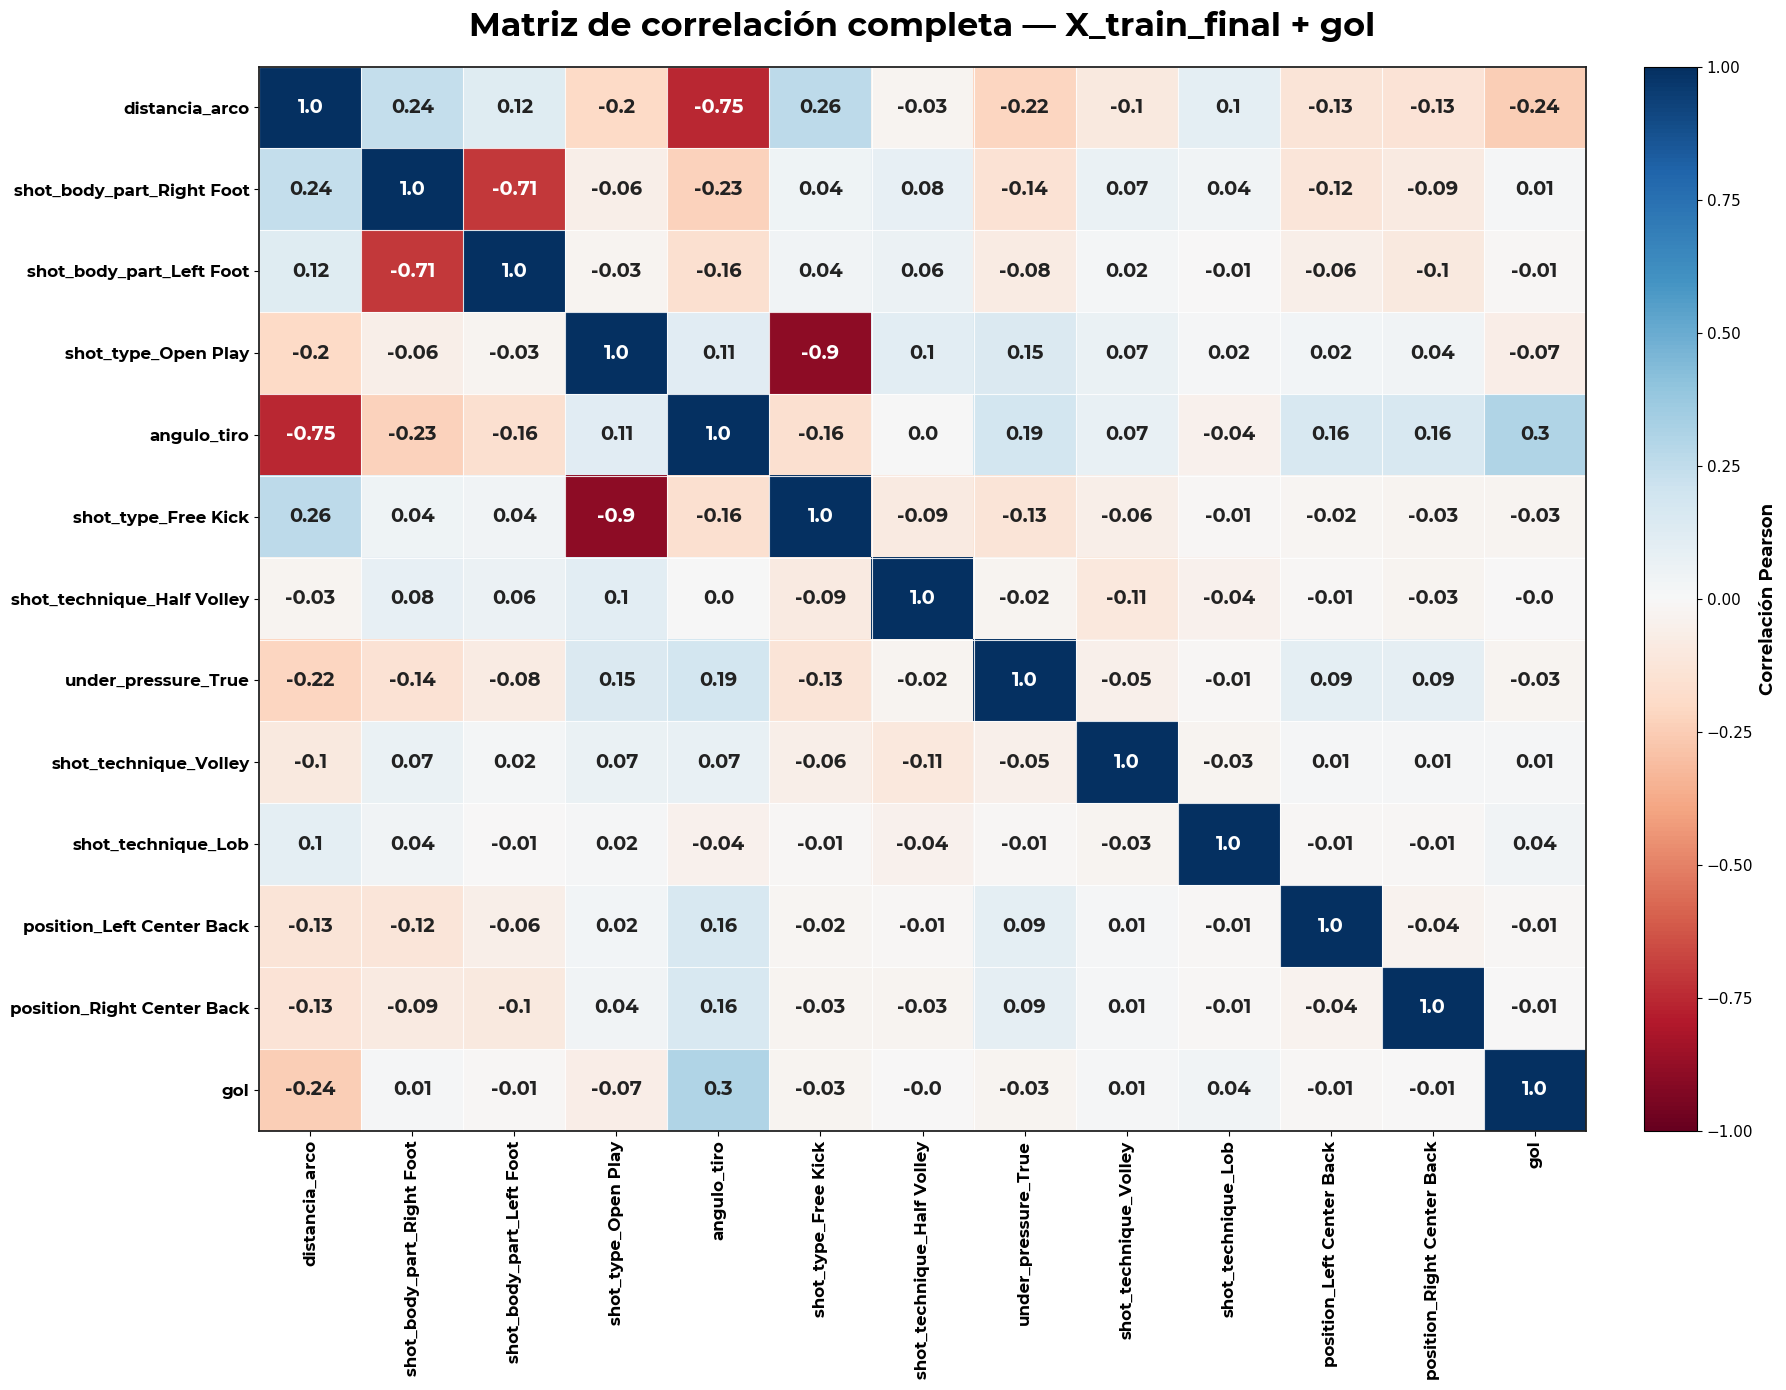

In [216]:
from matplotlib.colors import TwoSlopeNorm
import numpy as np

fuente_grafico = "Montserrat"

fig, ax = plt.subplots(
    figsize=(18, 14))

norm = TwoSlopeNorm(
    vmin=-1,
    vcenter=0,
    vmax=1)

imagen = ax.imshow(
    matriz_correlacion,
    cmap="RdBu",
    norm=norm,
    aspect="auto")

colorbar = fig.colorbar(
    imagen,
    ax=ax,
    fraction=0.046,
    pad=0.04)

colorbar.set_label(
    "Correlación Pearson",
    fontsize=13,
    fontweight="bold",
    fontname=fuente_grafico)

colorbar.ax.tick_params(labelsize=11)

ax.set_xticks(
    range(len(matriz_correlacion.columns)))

ax.set_yticks(
    range(len(matriz_correlacion.index)))

ax.set_xticklabels(
    matriz_correlacion.columns,
    rotation=90,
    fontsize=12,
    fontweight="bold",
    fontname=fuente_grafico)

ax.set_yticklabels(
    matriz_correlacion.index,
    fontsize=12,
    fontweight="bold",
    fontname=fuente_grafico)

ax.set_title(
    "Matriz de correlación completa — X_train_final + gol",
    fontsize=24,
    fontweight="bold",
    fontname=fuente_grafico,
    pad=22)

# Líneas divisorias entre celdas
ax.set_xticks(
    np.arange(-0.5, len(matriz_correlacion.columns), 1),
    minor=True)

ax.set_yticks(
    np.arange(-0.5, len(matriz_correlacion.index), 1),
    minor=True)

ax.grid(
    which="minor",
    color="white",
    linestyle="-",
    linewidth=0.8,
    alpha=0.85)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False)

# Valores dentro de cada celda
for i in range(len(matriz_correlacion.index)):
    
    for j in range(len(matriz_correlacion.columns)):
        
        valor = matriz_correlacion.iloc[i, j]
        
        if abs(valor) >= 0.55:
            color_texto = "white"
        else:
            color_texto = "#222222"
        
        ax.text(
            j,
            i,
            str(round(valor, 2)),
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            fontname=fuente_grafico,
            color=color_texto)

# Bordes externos
for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_linewidth(1.3)
    borde.set_color("#222222")

plt.tight_layout()
plt.show()

In [ ]:
pares_correlacion = []

columnas_corr = matriz_correlacion.columns.tolist()

for i in range(len(columnas_corr)):
    
    for j in range(i + 1, len(columnas_corr)):
        
        variable_1 = columnas_corr[i]
        variable_2 = columnas_corr[j]
        
        if variable_1 != "gol" and variable_2 != "gol":
            
            valor_corr = matriz_correlacion.loc[variable_1, variable_2]
            
            pares_correlacion.append({
                    "variable_1": variable_1,
                    "variable_2": variable_2,
                    "correlacion": valor_corr,
                    "correlacion_abs": abs(valor_corr)})
            
df_pares_correlacion = pd.DataFrame(pares_correlacion)

df_pares_correlacion = df_pares_correlacion.sort_values("correlacion_abs",ascending=False)

df_pares_correlacion.head(30)

,variable_1,variable_2,correlacion,correlacion_abs
31,shot_type_Open Play,shot_type_Free Kick,-0.896096,0.896096
3,distancia_arco,angulo_tiro,-0.750697,0.750697
11,shot_body_part_Right Foot,shot_body_part_Left Foot,-0.706187,0.706187
4,distancia_arco,shot_type_Free Kick,0.259618,0.259618
0,distancia_arco,shot_body_part_Right Foot,0.242079,0.242079
13,shot_body_part_Right Foot,angulo_tiro,-0.232924,0.232924
6,distancia_arco,under_pressure_True,-0.218579,0.218579
2,distancia_arco,shot_type_Open Play,-0.199790,0.199790
40,angulo_tiro,under_pressure_True,0.186542,0.186542
44,angulo_tiro,position_Right Center Back,0.162024,0.162024


In [172]:
from sklearn.linear_model import LogisticRegression

In [ ]:
modelo_logistico = LogisticRegression( penalty="l1", solver="liblinear", C=0.02, max_iter=10000)

In [175]:
modelo_logistico.fit(X_train_final, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.02
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass

In [176]:
prob_train = modelo_logistico.predict_proba(X_train_final)[:, 1]

prob_test = modelo_logistico.predict_proba(X_test_final)[:, 1]

prob_aplicacion = modelo_logistico.predict_proba(X_aplicacion_final)[:, 1]

In [177]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import log_loss
from sklearn.metrics import brier_score_loss

In [178]:
print("TRAIN")
print("AUC ROC:", round(roc_auc_score(y_train, prob_train), 4))
print("Average Precision:", round(average_precision_score(y_train, prob_train), 4))
print("Log Loss:", round(log_loss(y_train, prob_train), 4))
print("Brier Score:", round(brier_score_loss(y_train, prob_train), 4))
print("Goles reales:", int(y_train.sum()))
print("xG estimado:", round(prob_train.sum(), 2))

TRAIN
AUC ROC: 0.7927
Average Precision: 0.3906
Log Loss: 0.2749
Brier Score: 0.0784
Goles reales: 4943
xG estimado: 4992.85


In [179]:
print("TEST")
print("AUC ROC:", round(roc_auc_score(y_test, prob_test), 4))
print("Average Precision:", round(average_precision_score(y_test, prob_test), 4))
print("Log Loss:", round(log_loss(y_test, prob_test), 4))
print("Brier Score:", round(brier_score_loss(y_test, prob_test), 4))
print("Goles reales:", int(y_test.sum()))
print("xG estimado:", round(prob_test.sum(), 2))

TEST
AUC ROC: 0.7945
Average Precision: 0.4028
Log Loss: 0.2753
Brier Score: 0.0786
Goles reales: 1688
xG estimado: 1674.05


In [180]:
print("APLICACIÓN")
print("Tiros:", len(y_aplicacion))
print("Goles reales:", int(y_aplicacion.sum()))
print("xG estimado:", round(prob_aplicacion.sum(), 2))

APLICACIÓN
Tiros: 510
Goles reales: 57
xG estimado: 58.16


In [181]:
df_modelo_train["xg_logistico"] = prob_train

df_modelo_test["xg_logistico"] = prob_test

df_modelo_aplicacion["xg_logistico"] = prob_aplicacion

In [ ]:
#   df_modelo_train.to_csv(
#       ruta_processed / "df_modelo_xg_train_pred_logistico.csv",
#       index=False
#   )
#   
#   df_modelo_test.to_csv(
#       ruta_processed / "df_modelo_xg_test_pred_logistico.csv",
#       index=False
#   )
#   
#   df_modelo_aplicacion.to_csv(
#       ruta_processed / "df_modelo_xg_aplicacion_pred_logistico.csv",
#       index=False
#   )

In [182]:
y_test.mean()

0.10623033354310887

In [ ]:
nombres_variables_finales = list(X_train_final.columns)

coeficientes = modelo_logistico.coef_[0]

df_coeficientes = pd.DataFrame()

df_coeficientes["variable"] = nombres_variables_finales
df_coeficientes["coeficiente"] = coeficientes
df_coeficientes["odds_ratio"] = np.exp(coeficientes)
df_coeficientes["abs_coeficiente"] = abs(df_coeficientes["coeficiente"])

df_coeficientes.sort_values("coeficiente",ascending=False).head(25)

,variable,coeficiente,odds_ratio,abs_coeficiente
1,shot_body_part_Right Foot,1.124167,3.077651,1.124167
2,shot_body_part_Left Foot,1.040147,2.829633,1.040147
4,angulo_tiro,0.383948,1.468069,0.383948
9,shot_technique_Lob,0.328062,1.388275,0.328062
11,position_Right Center Back,-0.097875,0.906762,0.097875
10,position_Left Center Back,-0.173424,0.840781,0.173424
6,shot_technique_Half Volley,-0.262287,0.769290,0.262287
7,under_pressure_True,-0.298271,0.742101,0.298271
8,shot_technique_Volley,-0.322301,0.724480,0.322301
5,shot_type_Free Kick,-0.638327,0.528175,0.638327


In [ ]:
df_coeficientes.sort_values("coeficiente",ascending=True).head(25)

,variable,coeficiente,odds_ratio,abs_coeficiente
3,shot_type_Open Play,-1.819406,0.162122,1.819406
0,distancia_arco,-0.948989,0.387132,0.948989
5,shot_type_Free Kick,-0.638327,0.528175,0.638327
8,shot_technique_Volley,-0.322301,0.724480,0.322301
7,under_pressure_True,-0.298271,0.742101,0.298271
6,shot_technique_Half Volley,-0.262287,0.769290,0.262287
10,position_Left Center Back,-0.173424,0.840781,0.173424
11,position_Right Center Back,-0.097875,0.906762,0.097875
9,shot_technique_Lob,0.328062,1.388275,0.328062
4,angulo_tiro,0.383948,1.468069,0.383948


In [ ]:
df_coeficientes.sort_values("abs_coeficiente",ascending=False).head(30)

,variable,coeficiente,odds_ratio,abs_coeficiente
3,shot_type_Open Play,-1.819406,0.162122,1.819406
1,shot_body_part_Right Foot,1.124167,3.077651,1.124167
2,shot_body_part_Left Foot,1.040147,2.829633,1.040147
0,distancia_arco,-0.948989,0.387132,0.948989
5,shot_type_Free Kick,-0.638327,0.528175,0.638327
4,angulo_tiro,0.383948,1.468069,0.383948
9,shot_technique_Lob,0.328062,1.388275,0.328062
8,shot_technique_Volley,-0.322301,0.724480,0.322301
7,under_pressure_True,-0.298271,0.742101,0.298271
6,shot_technique_Half Volley,-0.262287,0.769290,0.262287


In [187]:
from sklearn.inspection import permutation_importance

In [ ]:
resultado_perm = permutation_importance(
    modelo_logistico,
    X_test_final,
    y_test,
    scoring="neg_log_loss",
    n_repeats=100,
    random_state=2026)

df_importancia = pd.DataFrame()

df_importancia["variable"] = X_test_final.columns
df_importancia["importancia_media"] = resultado_perm.importances_mean
df_importancia["importancia_std"] = resultado_perm.importances_std

df_importancia = df_importancia.sort_values("importancia_media",ascending=False)

df_importancia.head(20)

,variable,importancia_media,importancia_std
0,distancia_arco,0.067009,0.001880
1,shot_body_part_Right Foot,0.026663,0.001200
2,shot_body_part_Left Foot,0.020935,0.001074
3,shot_type_Open Play,0.019124,0.000933
4,angulo_tiro,0.018471,0.000810
5,shot_type_Free Kick,0.002351,0.000280
6,shot_technique_Half Volley,0.001501,0.000214
7,under_pressure_True,0.001285,0.000303
8,shot_technique_Volley,0.000603,0.000184
9,shot_technique_Lob,0.000430,0.000068


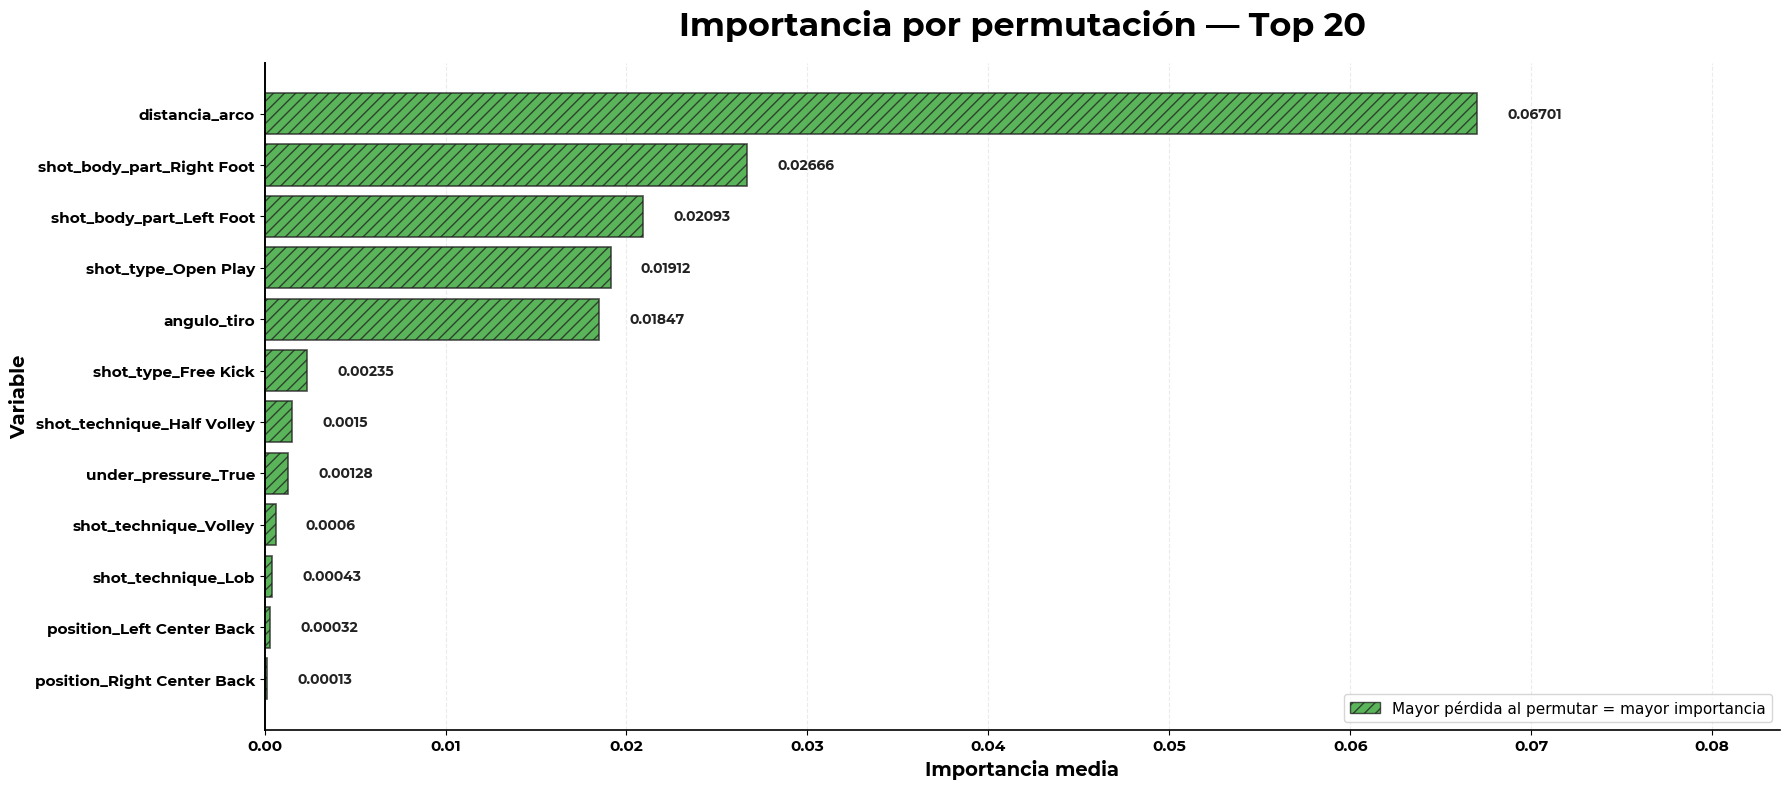

In [ ]:
fuente_grafico = "Montserrat"

df_top_importancia = df_importancia.head(20).copy()

df_top_importancia = df_top_importancia.sort_values(
    "importancia_media",
    ascending=True
)

fig, ax = plt.subplots(figsize=(18, 8))

barras = ax.barh(
    df_top_importancia["variable"],
    df_top_importancia["importancia_media"],
    color="tab:green",
    alpha=0.78,
    edgecolor="#222222",
    linewidth=1.2
)

for barra in barras:
    barra.set_hatch("///")

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.25
)

ax.set_axisbelow(True)

ax.set_title(
    "Importancia por permutación — Top 20",
    fontsize=24,
    fontweight="bold",
    fontname=fuente_grafico,
    pad=20
)

ax.set_xlabel(
    "Importancia media",
    fontsize=14,
    fontweight="bold",
    fontname=fuente_grafico
)

ax.set_ylabel(
    "Variable",
    fontsize=14,
    fontweight="bold",
    fontname=fuente_grafico
)

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

for etiqueta in ax.get_yticklabels():
    etiqueta.set_fontweight("bold")
    etiqueta.set_fontname(fuente_grafico)

for etiqueta in ax.get_xticklabels():
    etiqueta.set_fontweight("bold")
    etiqueta.set_fontname(fuente_grafico)

valor_maximo = df_top_importancia["importancia_media"].max()

margen_derecho = valor_maximo * 0.25

ax.set_xlim(0,valor_maximo + margen_derecho)

desplazamiento = valor_maximo * 0.025

for barra in barras:
    
    ancho = barra.get_width()
    y = barra.get_y() + barra.get_height() / 2
    
    ax.text(
        ancho + desplazamiento,
        y,
        str(round(ancho, 5)),
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        fontname=fuente_grafico,
        color="#222222"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.4)
ax.spines["bottom"].set_linewidth(1.2)

importancia_patch = plt.Rectangle(
    (0, 0),
    1,
    1,
    facecolor="tab:green",
    edgecolor="#222222",
    hatch="///",
    alpha=0.78,
    label="Mayor pérdida al permutar = mayor importancia")

ax.legend(handles=[importancia_patch],loc="lower right",fontsize=11,frameon=True)

plt.tight_layout()
plt.show()

In [192]:
coeficientes_l1 = modelo_logistico.coef_[0]

In [ ]:
df_coeficientes_l1 = pd.DataFrame()

df_coeficientes_l1["variable"] = X_train_final.columns
df_coeficientes_l1["coeficiente"] = coeficientes_l1
df_coeficientes_l1["coeficiente_abs"] = abs(df_coeficientes_l1["coeficiente"])

df_variables_seleccionadas_l1 = df_coeficientes_l1[df_coeficientes_l1["coeficiente"] != 0].copy()

df_variables_seleccionadas_l1 = df_variables_seleccionadas_l1.sort_values("coeficiente_abs",ascending=False)

df_variables_seleccionadas_l1

,variable,coeficiente,coeficiente_abs
3,shot_type_Open Play,-1.819406,1.819406
1,shot_body_part_Right Foot,1.124167,1.124167
2,shot_body_part_Left Foot,1.040147,1.040147
0,distancia_arco,-0.948989,0.948989
5,shot_type_Free Kick,-0.638327,0.638327
4,angulo_tiro,0.383948,0.383948
9,shot_technique_Lob,0.328062,0.328062
8,shot_technique_Volley,-0.322301,0.322301
7,under_pressure_True,-0.298271,0.298271
6,shot_technique_Half Volley,-0.262287,0.262287


In [196]:
df_variables_seleccionadas_l1.shape[0]

12

In [ ]:
df_variables_importantes = df_importancia[df_importancia["importancia_media"] > 0.0001].copy()

df_variables_importantes = df_variables_importantes.sort_values("importancia_media",ascending=False)

df_variables_importantes

,variable,importancia_media,importancia_std
0,distancia_arco,0.067009,0.001880
1,shot_body_part_Right Foot,0.026663,0.001200
2,shot_body_part_Left Foot,0.020935,0.001074
3,shot_type_Open Play,0.019124,0.000933
4,angulo_tiro,0.018471,0.000810
5,shot_type_Free Kick,0.002351,0.000280
6,shot_technique_Half Volley,0.001501,0.000214
7,under_pressure_True,0.001285,0.000303
8,shot_technique_Volley,0.000603,0.000184
9,shot_technique_Lob,0.000430,0.000068


In [198]:
columnas_modelo_final = X_train_final.columns.tolist()

columnas_modelo_final

['distancia_arco',
 'shot_body_part_Right Foot',
 'shot_body_part_Left Foot',
 'shot_type_Open Play',
 'angulo_tiro',
 'shot_type_Free Kick',
 'shot_technique_Half Volley',
 'under_pressure_True',
 'shot_technique_Volley',
 'shot_technique_Lob',
 'position_Left Center Back',
 'position_Right Center Back']

In [199]:
import joblib
import json

In [ ]:
joblib.dump(modelo_logistico,ruta_processed / "modelo_xg_logistico_12vars.joblib")

In [200]:
umbral_operativo = 0.211

In [201]:
metadata_modelo = {
    "nombre_modelo": "modelo_xg_logistico_12vars",
    "tipo_modelo": "Regresion logistica",
    "target": "gol",
    "columna_score": "xg_modelo",
    "umbral_operativo": umbral_operativo,
    "criterio_umbral_operativo": "umbral definido en train para igualar volumen de goles",
    "columnas_modelo_final": columnas_modelo_final
}

In [ ]:
with open(ruta_processed / "metadata_modelo_xg_logistico_12vars.json", "w", encoding="utf-8") as archivo:
    json.dump(metadata_modelo,archivo,ensure_ascii=False,indent=4)

In [ ]:
columnas_identificacion = [ "match_id", "match_date", "competition_name", "season_name", "season_year", "home_team", "away_team", "team", "player", "minute", "second", "shot_outcome", "shot_statsbomb_xg" ] 

In [203]:
columnas_identificacion_train = []

for columna in columnas_identificacion:
    
    if columna in df_modelo_train.columns:
        columnas_identificacion_train.append(columna)

columnas_identificacion_train

['match_id',
 'match_date',
 'competition_name',
 'season_name',
 'season_year',
 'home_team',
 'away_team',
 'team',
 'player',
 'minute',
 'second',
 'shot_outcome',
 'shot_statsbomb_xg']

In [ ]:
df_validacion_train = df_modelo_train[columnas_identificacion_train].copy().reset_index(drop=True)

df_validacion_train["dataset"] = "train"
df_validacion_train["gol"] = y_train.reset_index(drop=True)

df_validacion_train = pd.concat([df_validacion_train,X_train_final.reset_index(drop=True)],axis=1)

In [ ]:
df_validacion_test = df_modelo_test[columnas_identificacion_train].copy().reset_index(drop=True)

df_validacion_test["dataset"] = "test"
df_validacion_test["gol"] = y_test.reset_index(drop=True)

df_validacion_test = pd.concat([df_validacion_test,X_test_final.reset_index(drop=True)],axis=1)

In [ ]:
df_validacion_aplicacion = df_modelo_aplicacion[columnas_identificacion_train].copy().reset_index(drop=True)

df_validacion_aplicacion["dataset"] = "aplicacion"
df_validacion_aplicacion["gol"] = y_aplicacion.reset_index(drop=True)

df_validacion_aplicacion = pd.concat([df_validacion_aplicacion,X_aplicacion_final.reset_index(drop=True)],axis=1)

In [ ]:
df_validacion_modelo_xg = pd.concat([df_validacion_train,df_validacion_test,df_validacion_aplicacion],ignore_index=True)

In [ ]:
df_validacion_modelo_xg.groupby("dataset").agg(
    tiros=("gol", "count"),
    goles=("gol", "sum"))

,tiros,goles
dataset,,
aplicacion,510,57
test,15890,1688
train,47082,4943


In [ ]:
df_validacion_modelo_xg.to_csv(ruta_processed / "df_validacion_modelo_xg_12vars.csv",index=False)

In [ ]:
df_coeficientes_modelo = pd.DataFrame()

df_coeficientes_modelo["variable"] = columnas_modelo_final
df_coeficientes_modelo["coeficiente"] = modelo_logistico.coef_[0]
df_coeficientes_modelo["coeficiente_abs"] = abs(df_coeficientes_modelo["coeficiente"])
df_coeficientes_modelo["odds_ratio"] = np.exp(df_coeficientes_modelo["coeficiente"])

df_coeficientes_modelo = df_coeficientes_modelo.sort_values("coeficiente_abs",ascending=False)

df_coeficientes_modelo

,variable,coeficiente,coeficiente_abs,odds_ratio
3,shot_type_Open Play,-1.819406,1.819406,0.162122
1,shot_body_part_Right Foot,1.124167,1.124167,3.077651
2,shot_body_part_Left Foot,1.040147,1.040147,2.829633
0,distancia_arco,-0.948989,0.948989,0.387132
5,shot_type_Free Kick,-0.638327,0.638327,0.528175
4,angulo_tiro,0.383948,0.383948,1.468069
9,shot_technique_Lob,0.328062,0.328062,1.388275
8,shot_technique_Volley,-0.322301,0.322301,0.724480
7,under_pressure_True,-0.298271,0.298271,0.742101
6,shot_technique_Half Volley,-0.262287,0.262287,0.769290


In [ ]:
df_coeficientes_modelo.to_csv(ruta_processed / "df_coeficientes_modelo_xg_12vars.csv",index=False)

In [ ]:
df_importancia.to_csv(ruta_processed / "df_importancia_modelo_xg_12vars.csv",index=False)